In [ ]:
#임포트
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#드라이브 마운트
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
origin = '/content/drive/MyDrive/새싹과정/my/3주차/데이터/2차 실전 - 이커머스'

#csv 파일을 읽기(파일은 origin 경로의 '~' 파일 경로로 연결합니다)
#os.path.join(폴더 경로, 파일 경로)
customer = pd.read_csv(os.path.join (origin, 'Customer_info.csv'))
discount = pd.read_csv(os.path.join (origin, 'Discount_info.csv'))
marketing = pd.read_csv(os.path.join (origin, 'Marketing_info.csv'))
onlinesales = pd.read_csv(os.path.join (origin, 'Onlinesales_info.csv'))

#컬럼 찍어 정보 확인
print(customer.columns)
print(discount.columns)
print(marketing.columns)
print(onlinesales.columns)              #주 사용 데이터.

Index(['고객ID', '성별', '고객지역', '가입기간'], dtype='object')
Index(['월', '제품카테고리', '쿠폰코드', '할인율'], dtype='object')
Index(['날짜', '오프라인비용', '온라인비용'], dtype='object')
Index(['고객ID', '거래ID', '거래날짜', '제품ID', '제품카테고리', '수량', '평균금액', '배송료', '쿠폰상태'], dtype='object')


#마케팅 세그먼트

- 고객 세그먼트: 고객을 유형별 분류
    - 유형
    1. 구매 스타일
    2. 충성도 스타일
    3. 라이프 스타일 (코호트)

## 데이터 프레임 병합 (merge)

- 공통된 열을 바탕으로 2개 이상의 데이터 프레임을 결합시키는 것

In [ ]:
# 판다스 merge 사용 pd.merge(a,b)
bigdata = pd.merge(customer, onlinesales)
bigdata.head()

#파생변수 등은 df에 붙여서 작업, 원본 bigdata는 보존        습관화하세용
df= bigdata.copy()
df.head()

,고객ID,성별,고객지역,가입기간,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태
0,USER_1358,남,Chicago,12,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
1,USER_1358,남,Chicago,12,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
2,USER_1358,남,Chicago,12,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used
3,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used
4,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used


# 흐름 파악



# 1.아무것도 가공하지 않았을 때, 군집화
 - 내가 갖고 있는 데이터에서 수치로 된 데이터만 뽑아(인코딩도 안함) -> 군집화 하기
 - why? customer onlinesales 데이터 프레임이 충분한 데이터량을 갖고 있는지 확인용
 - 실루엣 계수 뽑아 확인(베이스 라인은 확보. 이정도 성능은 나오겠군~)

In [ ]:
#1. 사용할 데이터 열만 추출하기 (head 찍어서 사용가능한(숫자로만 이뤄진 것)것 체크함. 가능한 특징이 적어서 증강해가며 진행할 예정)
#문제점: 고객 기준으로 생성된 데이터가 아니라 '고객'을 기준으로 세그먼트를 가져와야함 (현재 데이터는 거래를 기준으로 생성되어 있음)

#문제점 해결부터: 같은 고객의 모든 거래 정보 합치기
#딕셔너리: agg.({키:값}) -> 키(열이름 값) : 값 (이 열에 대해 수행할 연산)
sample_df = df.groupby('고객ID').agg({'수량':'sum', '평균금액':'sum', '배송료':'mean', '가입기간': 'max'})

sample_df.head()

,수량,평균금액,배송료,가입기간
고객ID,,,,
USER_0000,3,25.49,75.000000,31
USER_0001,342,3746.16,11.085667,20
USER_0002,209,336.52,8.571739,39
USER_0003,21,1312.40,7.522353,25
USER_0004,56,1244.83,17.708056,31


In [ ]:
#전체 df에서 고객의 중복되지 않는 수
print(df['고객ID'].nunique(), len(sample_df))               #앞은 중복 제거한 총 고객 수, 뒤는 내가 정리한 (중복제거 처리) 고객 수. 서로 동일해야함.

1468 1468


## 1-1. 최적의 군집 개수 그려보자!

- 엘보우 그래프 활용.
- K개 군집(2~10) 마다 얼마나 군집 내 거리가 작아지는지 확인하기

In [ ]:
from sklearn.cluster import KMeans

#for 활용할거에용

iner = []           #k개 군집마다 각각 군집 내부 거리 저장

for k in range(2,11):
    km = KMeans(n_clusters = k)         #객체 생성(군집 개수는 k, k가 슥슥 돌아갈거지롱)
    km.fit(sample_df)                   #머신러닝용 정제 데이터 넣어주셈 (예쁜 학습지~)
    iner.append(km.inertia_)            #km은 스스로 저장해서 따로 할당하지 않아도 됨! 이 단계는 리스트에 k개로 나뉜 후의 내부 거리 저장

In [ ]:
#한국어

!apt-get install -y fonts-nanum

#맷플롯립 한국어 등록
import matplotlib.font_manager as fm

#한글 폰트 경로 알려줌
fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf',
                  name='NanumGothic')

fm.fontManager.ttflist.insert(0,fe)     #실제 ttf리스트의 가장 상단에 넣어라

plt.rcParams.update({'font.size':10, 'font.family':'NanumGothic'})      #폰트 사이즈, 폰트 패밀

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


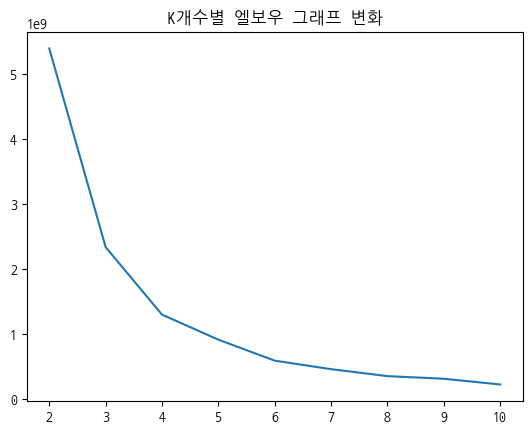

In [ ]:
#시각화
fig, ax = plt.subplots()
ax.plot(range(2,11),iner)

plt.title('K개수별 엘보우 그래프 변화')
plt.show()
#기준점 확인 완료

In [ ]:
#KMeans
km_5 = KMeans(n_clusters = 5)
km_5.fit(sample_df)
km5_predict = km_5.predict(sample_df)

#실루엣 계수
from sklearn.metrics import silhouette_score

#메트릭 함수 (정답, 나의 예측 ) -> 실루엣 (데이터, 나의 예측)
sc = silhouette_score(sample_df, km5_predict)

print (f'기본 데이터 X 군집이 5개일 때: {sc:.4f}')

기본 데이터 X 군집이 5개일 때: 0.5922


# 흐름 되짚기

- 현재 고객 세그먼트 분류
    - 거래 내역, 고객 정보 합침
- 전처리 없이 KMeans 활용
    - 최적의 n_estimator 도출
- 빈도 기준 세그먼트  (RMF 분석)
    - 최근: Recency
    - 자주: Frequency
    - 총 :Monetary
     - 이곳엔 도메인 지식을 활용 가능
    - 이 내용들을 바탕으로 전처리 실행
        - 인코딩
        - 도메인 지식 통해 파생변수 생성
    - 위에서 구한 최적 그룹 수(5)로 그룹화
    - 이후 실루엣 계수로 확인

# 2.RMF 분석

- Recency (가장 최근에 산 날)
- Frequency (얼마나 자주 샀는지)
- Monetary (총 금액이 얼마인지)

-> '헤비 유저', '라이트 유저' 구분

## 2-1. 파생변수 생성


In [ ]:
#'최근' 생성 (r_df)

#날짜 to_datetime 이용해 거래 날짜의 최근을 가져옴
#날짜 형태로 연도,월,일 분리 가능
df['거래날짜'] = pd.to_datetime(df['거래날짜'])

#agg(최근거래날짜 (새로운 열이름) = ('거래날짜'(무엇을),'max'(어떻게))
#reset_index(): 인덱스 값 초기화 (0~)
r_df = df.groupby('고객ID').agg(최근거래날짜 = ('거래날짜', 'max')).reset_index()
#다음과 같은 내용: r_df['최근거래날짜'] = df.groupby('고객ID').agg({'거래날짜' : 'max'})

r_df

,고객ID,최근거래날짜
0,USER_0000,2019-09-15
1,USER_0001,2019-11-02
2,USER_0002,2019-10-19
3,USER_0003,2019-12-14
4,USER_0004,2019-09-15
...,...,...
1463,USER_1463,2019-04-05
1464,USER_1464,2019-10-05
1465,USER_1465,2019-06-20
1466,USER_1466,2019-10-23


In [ ]:
#최근 날짜로만 파악이 어려우니 기준 날짜를 지정해서 이보다 며칠 지났는지.
# 최근 (2019-09-15) / (2019-10-23) 비교했을 때 후자가 더 우량 고객일 확률이 높다. 일수를 세서 간격을 보는 방법.
# 갖고 있는 데이터의 생성 날짜를 기준으로 (왜 이걸 기준?: 가장 최근의 기록이기 때문)

base_date = df['거래날짜'].max()            #내가 매월 거래 기록을 다운로드, 갖고 있는 날짜 중 가장 최신 날짜가 가깝기에.

#우량고객
# 기준 날짜 - 고객 마지막 거래 날짜 = 차이가 적다 = 최근 거래한 고객 = 우량 고객
#.dt.days : 차이나는 날짜의 숫자만 입력됨
r_df['recency'] = (base_date - r_df['최근거래날짜']).dt.days                #날짜 차이 값만 나옴.

r_df.head()

,고객ID,최근거래날짜,recency
0,USER_0000,2019-09-15,107
1,USER_0001,2019-11-02,59
2,USER_0002,2019-10-19,73
3,USER_0003,2019-12-14,17
4,USER_0004,2019-09-15,107


In [ ]:
# '빈도' 생성 (f_df)
# 방법 두 개
# 1. 고유 거래 횟수 구하기 (정석): 1번 거래 = 1건 카운트                       필요하면 그때그때 사는 편
f_df = df.groupby('고객ID').agg(Frequency = ('거래ID', 'nunique')).reset_index()        #한 고객이 몇 번 들어왔게

# 2. 구매한 제품개수:거래 1건 안에 포함되는 물품 개수 카운트                빈도가 적지만 주문량이 많을 때
temp = df.groupby('고객ID').agg(총구매건수 = ('수량', 'count')).reset_index()           #한 고객이 총 몇 건 샀게

#붙일 때 인덱스 같이 통일하거라

fr_df = pd.concat([f_df, temp['총구매건수']], axis = 1)
fr_df.head()

,고객ID,Frequency,총구매건수
0,USER_0000,1,2
1,USER_0001,31,60
2,USER_0002,8,23
3,USER_0003,11,17
4,USER_0004,13,36


In [ ]:
# '총 비용' (m_df)          #여기 차근히 봅시다..
# Monetary -> 우리 쇼핑 몰에서 돈 얼마나 썼니?
m_df = pd.DataFrame()
m_df['건당구매평균'] = df['수량'] * df['평균금액']
m_df['건별지출액'] = m_df['건당구매평균'] + df['배송료']
#여기까지만 하면 한 고객의 거래 건으로 나옴
m_df['고객ID'] = df['고객ID']           #각 거래별 어떤 고객인지 다시 붙임 이후 고객별로 다시 groupby 진행

    #고객별로 거래 횟수, 순 매출액 총 지출액 나옴.
money_df=m_df.groupby('고객ID').agg(총거래횟수 =('고객ID','count'), 순매출액 = ('건당구매평균', 'sum'), 총지출액 = ('건별지출액', 'sum')).reset_index()
money_df.head()

,고객ID,총거래횟수,순매출액,총지출액
0,USER_0000,2,30.99,180.99
1,USER_0001,60,13834.90,14500.04
2,USER_0002,23,1442.12,1639.27
3,USER_0003,17,1360.07,1487.95
4,USER_0004,36,1442.47,2079.96


In [ ]:
#r, f, m 합치기 (최근 빈도 돈 ) -> 1 df로 만들어서 군집 5개 나누기

rmf_result = pd.concat([money_df, fr_df, r_df], axis = 1)
rmf_result.head()

,고객ID,총거래횟수,순매출액,총지출액,고객ID,Frequency,총구매건수,고객ID,최근거래날짜,recency
0,USER_0000,2,30.99,180.99,USER_0000,1,2,USER_0000,2019-09-15,107
1,USER_0001,60,13834.90,14500.04,USER_0001,31,60,USER_0001,2019-11-02,59
2,USER_0002,23,1442.12,1639.27,USER_0002,8,23,USER_0002,2019-10-19,73
3,USER_0003,17,1360.07,1487.95,USER_0003,11,17,USER_0003,2019-12-14,17
4,USER_0004,36,1442.47,2079.96,USER_0004,13,36,USER_0004,2019-09-15,107


In [ ]:
# 머신러닝용으로 발췌 ㄱㄱ
rmf_result = rmf_result[['총거래횟수', '순매출액', '총지출액', 'Frequency', 'recency']]

rmf_result

,총거래횟수,순매출액,총지출액,Frequency,recency
0,2,30.99,180.99,1,107
1,60,13834.90,14500.04,31,59
2,23,1442.12,1639.27,8,73
3,17,1360.07,1487.95,11,17
4,36,1442.47,2079.96,13,107
...,...,...,...,...,...
1463,7,544.34,822.67,3,270
1464,40,2363.05,2995.47,19,87
1465,8,101.56,153.06,2,194
1466,1,298.00,304.00,1,69


In [ ]:
#군집화 ㄱㄱ

km_5_rmf = KMeans(n_clusters = 5)
km_5_rmf.fit(rmf_result)

km_5_rmf_result = km_5_rmf.predict(rmf_result)
km_5_rmf_sc = silhouette_score(rmf_result, km_5_rmf_result)
print(f'rmf 분석, 5개 군집 실루엣 계수: {km_5_rmf_sc:.4f}')

rmf 분석, 5개 군집 실루엣 계수: 0.6219


# Q. 어떤 군집화 알고리즘이 제일 잘 맞을까?

- 데이터의 군집을 시각화 해서 알아보기

- 어떤 종류의 군집화 알고리즘이 맞을지 '대략적'으로 알 수 있음

- -> df의 특징을 2차원이나 3차원으로 차원 축소
- -> 축소된 것을 산점도로 시각화

 - case1 :둥글게 모여 있는 경우
  -> 거리 기반 알고리즘이 더 좋음 (KMeans)
 - case2: 초승달, 도넛, 길쭉 등
  -> 밀도 기반 알고리즘이 더 좋음 (DBSCAN)


  이런 절차는 초반에 시각화 해서 위의 절차들을 진행하면 좋을 듯?

In [ ]:
# 2차원으로 차원 축소 -> 2 features
# 3차원으로 차원 축소 -> 3 features
df.head()

,고객ID,성별,고객지역,가입기간,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태
0,USER_1358,남,Chicago,12,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
1,USER_1358,남,Chicago,12,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
2,USER_1358,남,Chicago,12,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used
3,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used
4,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used


In [ ]:
df['고객지역'].unique()

array(['Chicago', 'California', 'New York', 'New Jersey', 'Washington DC'],
      dtype=object)

In [ ]:
#차원 축소할 때, 머신러닝 알고리즘에 적용할 열 중 '숫자가 아닌 것'을 인코딩

#인코딩 진행 (컬럼별 값 확인하려면 df[컬럼].unique)
#라벨 인코딩 -> 우열의 개념이 생길 수 있음(위험이 있음)
# 가능한 것: 제품카테고리, 쿠폰상태
from sklearn.preprocessing import LabelEncoder

#for문으로 {} 각 인코딩 열을 저장: 여러 열을 돌리기에!
col = ['제품카테고리', '쿠폰상태']
result = {}

for c in col :
    le = LabelEncoder()         #라벨인코더는 한번에 한 열만 가능
    df_le = le.fit_transform(df[c])
    result[c] = df_le

result = pd.DataFrame(result)
result.columns = ['카테고리_fix', '쿠폰상태_fix']

#원핫 인코딩 -> 우열의 개념이 없는 경우
# 유니크 값이 많이 없어야 함. 너무 많으면: 그거 그대로 열이 늘어남
# 가능한 것: 성별, 고객지역
#실무에서는 판다스, getdummies 사용함
from sklearn.preprocessing import OneHotEncoder


col2 = ['성별', '고객지역']
df_onehot = pd.get_dummies(df, columns = col2, dtype = int)
df_onehot.head()




,고객ID,가입기간,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,성별_남,성별_여,고객지역_California,고객지역_Chicago,고객지역_New Jersey,고객지역_New York,고객지역_Washington DC
0,USER_1358,12,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,0,0,1,0,0,0
1,USER_1358,12,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,0,0,1,0,0,0
2,USER_1358,12,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1,0,0,1,0,0,0
3,USER_1358,12,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1,0,0,1,0,0,0
4,USER_1358,12,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1,0,0,1,0,0,0


In [ ]:
#원핫에 있는 열 그대로 살리기+ 라벨인코딩 열 가져오고 + 필요없는거 드롭
result.columns = ['카테고리_fix', '쿠폰상태_fix']
graph = pd.concat([df_onehot, result], axis = 1)

graph.drop(columns = ['고객ID', '거래ID', '거래날짜', '제품ID','제품카테고리', '쿠폰상태' ], inplace = True)

In [ ]:
graph

,가입기간,수량,평균금액,배송료,성별_남,성별_여,고객지역_California,고객지역_Chicago,고객지역_New Jersey,고객지역_New York,고객지역_Washington DC,카테고리_fix,쿠폰상태_fix
0,12,1,153.71,6.50,1,0,0,1,0,0,0,16,2
1,12,1,153.71,6.50,1,0,0,1,0,0,0,16,2
2,12,1,2.05,6.50,1,0,0,1,0,0,0,18,2
3,12,5,17.53,6.50,1,0,0,1,0,0,0,2,1
4,12,1,16.50,6.50,1,0,0,1,0,0,0,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,45,1,121.30,6.50,0,1,0,0,0,1,0,16,0
52920,45,1,48.92,6.50,0,1,0,0,0,1,0,2,2
52921,45,1,151.88,6.50,0,1,0,0,0,1,0,16,2
52922,7,5,80.52,6.50,0,1,1,0,0,0,0,16,0


In [ ]:
#3차원 값으로 축소
from sklearn.decomposition import PCA


pca = PCA(n_components = 3)
x_pca = pca.fit_transform(graph)

In [ ]:
pd.DataFrame(x_pca)

,0,1,2
0,101.791308,0.379603,-0.184003
1,101.791308,0.379603,-0.184003
2,-49.394253,-7.464249,-0.733047
3,-34.845854,-4.283671,-2.911595
4,-35.621617,-7.308249,-0.389168
...,...,...,...
52919,69.457910,-1.448367,-1.318009
52920,-3.380345,-5.832236,-1.264876
52921,99.960604,0.150510,-1.216394
52922,28.626677,-0.370167,-2.840631


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothicCoding.
  fig.canvas.print_figure(bytes_io, **kw)


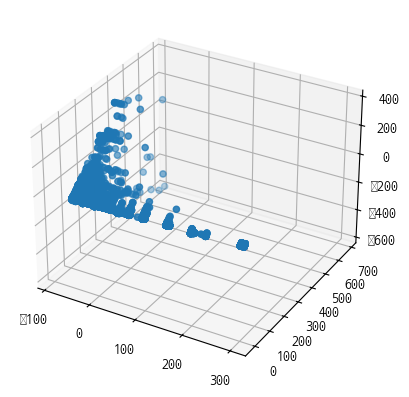

In [ ]:
#kwargs / projection (투영): 3차원
#subplot_kw= {'projection': '3d'} 추가해서 3차원~
fig, ax = plt.subplots(subplot_kw= {'projection': '3d'})

ax.scatter(x_pca[:,0], x_pca[:, 1], x_pca[:,2])
plt.show()

#결과 보고 kmeans 보다 다른거 써야쥐~ 판단

## 모듈화
데이터 확인, 전처리, 모델링, 평가 의 흐름

시각화라는 툴 활용해서 모델링을 뭘할지 판단 할 것

시각화는 모델링 전

전처리한 것을 갖고 시각화를 해야함
- 왜?
1. 전처리 = 수치화된 것
2. 전처리 끝난 결과 = 모델링 인풋 대상
전처리를 재료로 시각화!

함수로 모듈화에서 중요한 것
인앤아웃풋의 자료형 맞추기 -> 정의(what)

def 3d(전처리된 데이터프레임):
    1. 데프가 열이 몇 개든 3차원화 시켜야함 (시각화니까), 즉 새로운 pca 정의 (n-comp~3)
    2. fit transform
    3. 시각화
이 상태에선 리턴 안 해도 됨

** ^함수 부분에서는 수정용으로 보셔용~**

In [ ]:
#모듈화 할때는 아래와 같이 명시하기

#입력: 데이터 프레임
#출력: 3d 이미지 (plt.show())

In [ ]:
# def Dim3 (graph):
#     #1. 3차원 차원 축소
#     pca_n1 = PCA(n_components =3)

#     #2. fit_transform
#     pca_1 = pca_n1.fit_transform(graph)                    #???

#     #3. 시각화
#     fig, ax = plt.subplots()

In [ ]:
#쌤 풀이
# 알고리즘 전, 전처리 후 이 함수 실행하면 어떤 알고리즘 선택할지 파악 가능!
#입력: 데이터 프레임    출력
def visual3d (df_):
    #1. 3차원 축소
    pca = PCA(n_components = 3)
    x_pca_ = pca.fit_transform(df_)

    #2. 시각화
    fig, ax = plt.subplots(subplot_kw = {'projection': '3d'})
    ax.scatter(x_pca_[:, 0], x_pca_[:,1], x_pca_[:,2])

    plt.show()

#왓 딛아 미스: 매개 변수 이름 안 겹치게
#정리포인트: 정제한 데이터들이 어떤 것이 있는지 걔네는 어디에서 쓰이는지, 흐름 잡기!!

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothicCoding.
  fig.canvas.print_figure(bytes_io, **kw)


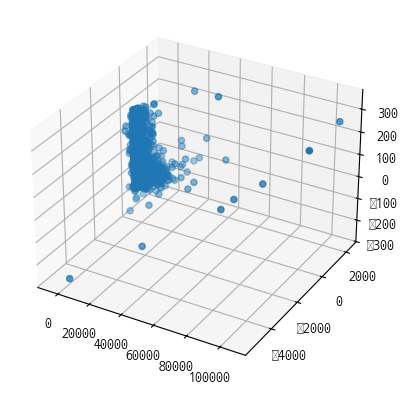

In [ ]:
#rmf 데이터 프레임으로 적용
visual3d(rmf_result)

# 2.업리프팅 모델

- '할인 행사'가 먹히는 고객 VS. 아닌 고객
- 고객이 설득 가능한지, 마케팅 효과가 큰지에 따라 세그먼트를 나누는 방법

- 설득 가능(이벤트로 유도가 되는), 집토끼(잡은 물고기), 난공불락(무슨 짓을 해도 안 삼), 깨우지마시오(스팸취급) 군


In [ ]:
#컬럼 찍어보기
print( customer.columns )
print( discount.columns )
print( marketing.columns )
print( onlinesales.columns )

Index(['고객ID', '성별', '고객지역', '가입기간'], dtype='object')
Index(['월', '제품카테고리', '쿠폰코드', '할인율'], dtype='object')
Index(['날짜', '오프라인비용', '온라인비용'], dtype='object')
Index(['고객ID', '거래ID', '거래날짜', '제품ID', '제품카테고리', '수량', '평균금액', '배송료', '쿠폰상태'], dtype='object')


In [ ]:
#1. merge(onlinesales, discount) => '월'/'제품카테고리' (그 월에 무슨 행사했는데?)
#주의: 서로 공통점이 없음. 양쪽 다 인코딩 진행햐

#1-1. 디스카운트의 '월'을 숫자 '월'로 변환
#discount['월'].replace({}) : 우리가 이미 뭘 어떻게 바꿀지 알고 있으니까 replace 사용
discount['월'].replace({'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4,
                       'May':5, 'Jun':6, 'Jul':7, 'Aug':8, 'Sep':9,
                        'Oct':10, 'Nov':11, 'Dec':12}, inplace=True)
discount.head()

/tmp/ipykernel_2654/620933639.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  discount['월'].replace({'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4,
/tmp/ipykernel_2654/620933639.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  discount['월'].replace({'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4,


,월,제품카테고리,쿠폰코드,할인율
0,1,Apparel,SALE10,10
1,2,Apparel,SALE20,20
2,3,Apparel,SALE30,30
3,1,Nest-USA,ELEC10,10
4,2,Nest-USA,ELEC20,20


In [ ]:
# 거래날짜의 월만 추출하여 위의 디스카운트와 행태 동일화
df = onlinesales.copy()
df['월'] = pd.to_datetime(df['거래날짜']).dt.month.astype(int)
df.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1


In [ ]:
#머지 실행
            #df, discount 순서 주의

# df를 우선으로 (how) discount 합쳐줘. 단, on('월', '제품카테고리')가 맞는 행을 찾아 붙여줘
# left join 과 연관 있습니당
#on = ['월', '제품카테고리']
#how = 'left'
X = pd.merge(df, discount, on = ['월', '제품카테고리'], how = 'left')

X.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월,쿠폰코드,할인율
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,ELEC10,10.0
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,ELEC10,10.0
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1,OFF10,10.0
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1,SALE10,10.0
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1,AIO10,10.0


In [ ]:
X.isnull().sum()
#왜 X에 붙인 열들만 결측치가 생겼는가?: 쿠폰발행월이 아닌 월에 제품을 구매한 것


#결측치 처리: 0으로
X['할인율'] = X['할인율'].fillna(0)
X['쿠폰코드'] = X['쿠폰코드'].fillna('--')
X.isnull().sum()

,0
고객ID,0
거래ID,0
거래날짜,0
제품ID,0
제품카테고리,0
수량,0
평균금액,0
배송료,0
쿠폰상태,0
월,0


In [ ]:
# 바꿀 점:
#쿠폰을 사용하지 않은 사람들의 할인율을 0으로 변경
X.loc[X['쿠폰상태']!= 'Used','할인율'] = 0

X.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월,쿠폰코드,할인율
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,ELEC10,10.0
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,ELEC10,10.0
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1,OFF10,10.0
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1,SALE10,0.0
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1,AIO10,10.0


In [ ]:
# 파생변수 생성

X['건별_순매출액'] = X['수량'] * X['평균금액']
X['건별_할인액'] = X['건별_순매출액'] * X['할인율'] * 0.01
X['건별_총지출액'] = (X['건별_순매출액'] - X['건별_할인액']) + X['배송료']

X

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월,쿠폰코드,할인율,건별_순매출액,건별_할인액,건별_총지출액
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.50,Used,1,ELEC10,10.0,153.71,15.371,144.839
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.50,Used,1,ELEC10,10.0,153.71,15.371,144.839
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.50,Used,1,OFF10,10.0,2.05,0.205,8.345
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.50,Not Used,1,SALE10,0.0,87.65,0.000,94.150
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.50,Used,1,AIO10,10.0,16.50,1.650,21.350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,USER_0504,Transaction_25056,2019-12-31,Product_0976,Nest-USA,1,121.30,6.50,Clicked,12,ELEC30,0.0,121.30,0.000,127.800
52920,USER_0504,Transaction_25057,2019-12-31,Product_0413,Apparel,1,48.92,6.50,Used,12,SALE30,30.0,48.92,14.676,40.744
52921,USER_0504,Transaction_25058,2019-12-31,Product_0989,Nest-USA,1,151.88,6.50,Used,12,ELEC30,30.0,151.88,45.564,112.816
52922,USER_0562,Transaction_25059,2019-12-31,Product_0985,Nest-USA,5,80.52,6.50,Clicked,12,ELEC30,0.0,402.60,0.000,409.100


In [ ]:
#rmf 요인 + 마케팅 요인 같이 남겨서 새로운 데프화

#rmf 재계산
base_date = X['거래날짜'].max()

#
df_features = X.groupby('고객ID').agg(
    최근거래일 = ('거래날짜', 'max'),
    Frequency =('거래ID', 'count'),
    순매출액 = ('건별_순매출액', 'sum'),
    총할인액 = ('건별_할인액', 'sum'),
    총지출액 = ('건별_총지출액', 'sum')
).reset_index()

In [ ]:
df_features

#최근거래일은 수정이 필요합니당

,고객ID,최근거래일,Frequency,순매출액,총할인액,총지출액
0,USER_0000,2019-09-15,2,30.99,9.297,171.693
1,USER_0001,2019-11-02,60,13834.90,781.548,13718.492
2,USER_0002,2019-10-19,23,1442.12,130.705,1508.565
3,USER_0003,2019-12-14,17,1360.07,152.217,1335.733
4,USER_0004,2019-09-15,36,1442.47,206.748,1873.212
...,...,...,...,...,...,...
1463,USER_1463,2019-04-05,7,544.34,11.190,811.480
1464,USER_1464,2019-10-05,40,2363.05,230.312,2765.158
1465,USER_1465,2019-06-20,8,101.56,3.563,149.497
1466,USER_1466,2019-10-23,1,298.00,0.000,304.000


In [ ]:
#recency 계산 관련하여
#dt_obj - df_features['최근거래일'] 둘 중 오류가 났음 (str이라 계산 불가)
#dt_obj = > 원래는 base_date
#판다스에만 datetime/python 내장 모듈. (별도 설치 x, datetime)


#%Y( year 양식으로 표기 ) '1999-01-01'
from datetime import datetime
dt_obj = datetime.strptime(base_date, "%Y-%m-%d")

print(dt_obj, type(dt_obj))

2019-12-31 00:00:00 <class 'datetime.datetime'>


In [ ]:
#최근거래일
#기준일로부터 마지막 구매가 얼마나 차이 나는지
df_features['최근거래일'] = pd.to_datetime(df_features['최근거래일'])
df_features['recency'] = (dt_obj - df_features['최근거래일']).dt.days

#평균구매 금액
df_features['평균구매금액'] = df_features['총지출액'] / df_features ['Frequency']

df_features

,고객ID,최근거래일,Frequency,순매출액,총할인액,총지출액,recency,평균구매금액
0,USER_0000,2019-09-15,2,30.99,9.297,171.693,107,85.846500
1,USER_0001,2019-11-02,60,13834.90,781.548,13718.492,59,228.641533
2,USER_0002,2019-10-19,23,1442.12,130.705,1508.565,73,65.589783
3,USER_0003,2019-12-14,17,1360.07,152.217,1335.733,17,78.572529
4,USER_0004,2019-09-15,36,1442.47,206.748,1873.212,107,52.033667
...,...,...,...,...,...,...,...,...
1463,USER_1463,2019-04-05,7,544.34,11.190,811.480,270,115.925714
1464,USER_1464,2019-10-05,40,2363.05,230.312,2765.158,87,69.128950
1465,USER_1465,2019-06-20,8,101.56,3.563,149.497,194,18.687125
1466,USER_1466,2019-10-23,1,298.00,0.000,304.000,69,304.000000


In [ ]:
#군집화

#사용하려는 컬럼만 남기기
#우선: 리셋 인덱스 실시

df_features.drop(columns=['최근거래일', '고객ID'],inplace=True)

df_features.head()

,Frequency,순매출액,총할인액,총지출액,recency,평균구매금액
0,2,30.99,9.297,171.693,107,85.846500
1,60,13834.90,781.548,13718.492,59,228.641533
2,23,1442.12,130.705,1508.565,73,65.589783
3,17,1360.07,152.217,1335.733,17,78.572529
4,36,1442.47,206.748,1873.212,107,52.033667


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothicCoding.
  fig.canvas.print_figure(bytes_io, **kw)


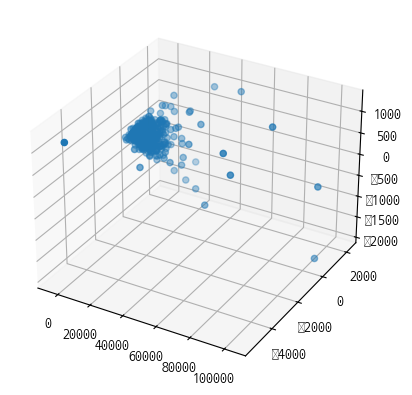

In [ ]:
visual3d(df_features)

In [ ]:
#결과 보고 알고리즘 선택하시오
#둥글둥글, KMeans


km_5_discount = KMeans(n_clusters = 2)
km_5_discount.fit(df_features)
km_5_discount_result = km_5_discount.predict(df_features)

km_5_discount_sc = silhouette_score(df_features, km_5_discount_result)
print(f'할인파생변수를 넣은 km 5개 군집의 실루엣 계수: {km_5_discount_sc}')

할인파생변수를 넣은 km 5개 군집의 실루엣 계수: 0.9277731352156929
